<a href="https://colab.research.google.com/github/crystalclcm/Dissertation-Crystal-Matticks/blob/main/02_job_ads_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [936]:
import requests
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive')


Mounted at /content/drive


['Easilet Lease Control Sheet.xlsx',
 'Easilet Lease Control Sheet.gsheet',
 'Car Spaces  Byrne Moore.xls',
 'Car Spaces  Byrne Moore.gsheet',
 'BW Contact Listing.xlsx',
 'BW Contact Listing.gsheet',
 'RH Customer listing.xlsx',
 'Parking control listing.xlsx',
 'Parking control listing.gsheet',
 'RH Customer listing.gsheet',
 'GLS Customer Listing.xlsx',
 'GLS Customer Listing.gsheet',
 'BM Listing.xlsx',
 'BM Listing.gsheet',
 'GCV Supplier Listing.xlsx',
 'GCV Supplier Listing.gsheet',
 'lease of unit 5, bymac(part 1).pdf',
 '30A BW lease agreement (second half).pdf',
 '30A BW lease agreement (first half).pdf',
 'lease of unit 5, bymac(part 2).pdf',
 '6 ferndale road letter of engagement.pdf',
 '36 st. fintan villas letter of engagement.pdf',
 '36 st. fintan villas lease agreement (part 1).pdf',
 '36 st.fintan villas lease agreement (part 2).pdf',
 '68 st. fintan villas letter of engagement.pdf',
 'index.pdf',
 'Document31 (2).pdf',
 'Document31 (2).gdoc',
 'Colab Notebooks',
 'Unt

In [226]:
pre_ai = pd.read_csv('/content/drive/MyDrive/pre_ai_full.csv')
post_ai = pd.read_csv('/content/adzuna_post_ai_final.csv')



In [582]:
Job_Postings = pd.read_csv('/content/JobPostings.csv')


In [227]:
pre_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role', 'source_clean', 'skills'],
      dtype='object')

In [228]:
post_ai.columns


Index(['job_title', 'job_description', 'country', 'date_posted', 'source',
       'role'],
      dtype='object')

# standardise and align datasets

In [229]:
import pandas as pd


#STANDARDISE PRE-AI DATASET
pre_ai_clean = pre_ai.copy()

pre_ai_clean = pre_ai_clean.rename(columns={
    'job_title': 'job_title',
    'job_description': 'raw_text',
    'date_posted': 'date_posted',
    'source_clean': 'source',
    'skills': 'skills_text'
})

# STANDARDISE FIRST POST-AI DATASET (Adzuna)
post_ai_clean = post_ai.copy()

post_ai_clean = post_ai_clean.rename(columns={
    'job_title': 'job_title',
    'description': 'raw_text',
    'created': 'date_posted',
    'company': 'company',
    'location': 'location',
    'redirect_url': 'redirect_url'
})

#STANDARDISE SECOND POST-AI DATASET (Job_Postings)
post_ai_extra_clean = Job_Postings.copy()

post_ai_extra_clean = post_ai_extra_clean.rename(columns={
    'title': 'job_title',
    'full_description': 'raw_text',
    'created': 'date_posted',
    'skills_list': 'skills_text',
    'home_url': 'home_url'
})

#DEFINE UNIFIED SCHEMA
unified_columns = [
    'job_title', 'company', 'location', 'country', 'date_posted', 'role',
    'source', 'industry', 'contract_type', 'contract_time',
    'salary_min', 'salary_max', 'salary_avg',
    'raw_text', 'clean_text', 'skills_text', 'seniority',
    'redirect_url', 'home_url'
]

#ADD ANY MISSING COLUMNS TO ALL DATASETS
for df in [pre_ai_clean, post_ai_clean, post_ai_extra_clean]:
    for col in unified_columns:
        if col not in df.columns:
            df[col] = None

#SELECT COLUMNS IN UNIFIED ORDER
pre_ai_clean = pre_ai_clean[unified_columns]
post_ai_clean = post_ai_clean[unified_columns]
post_ai_extra_clean = post_ai_extra_clean[unified_columns]

print("Standardisation complete.")


Standardisation complete.


In [230]:
def basic_clean(text):
    if pd.isna(text):
        return None
    text = str(text)
    text = text.lower()
    text = text.replace("\n", " ")
    text = " ".join(text.split())
    return text

pre_ai_clean["clean_text"] = pre_ai_clean["raw_text"].apply(basic_clean)
post_ai_clean["clean_text"] = post_ai_clean["raw_text"].apply(basic_clean)
post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)

print("Basic cleaning done.")


Basic cleaning done.


/tmp/ipykernel_1618/3995996791.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_ai_extra_clean["clean_text"] = post_ai_extra_clean["raw_text"].apply(basic_clean)


In [231]:
print("PRE-AI duplicates:", pre_ai_clean.columns.duplicated().any())
print("POST-AI duplicates:", post_ai_clean.columns.duplicated().any())
print("EXTRA POST-AI duplicates:", post_ai_extra_clean.columns.duplicated().any())


PRE-AI duplicates: True
POST-AI duplicates: False
EXTRA POST-AI duplicates: False


In [232]:
# Remove duplicate columns from PRE-AI
pre_ai_clean = pre_ai_clean.loc[:, ~pre_ai_clean.columns.duplicated()]
print("PRE-AI duplicate columns removed.")


PRE-AI duplicate columns removed.


In [233]:
# Find columns all datasets share
common_cols = list(
    set(pre_ai_clean.columns) &
    set(post_ai_clean.columns) &
    set(post_ai_extra_clean.columns)
)

print("Number of shared columns:", len(common_cols))
print("Shared columns:", common_cols)


Number of shared columns: 19
Shared columns: ['job_title', 'date_posted', 'salary_max', 'salary_min', 'company', 'contract_type', 'source', 'salary_avg', 'role', 'raw_text', 'location', 'home_url', 'country', 'skills_text', 'seniority', 'industry', 'redirect_url', 'contract_time', 'clean_text']


In [234]:
pre_ai_clean = pre_ai_clean[common_cols]
post_ai_clean = post_ai_clean[common_cols]
post_ai_extra_clean = post_ai_extra_clean[common_cols]

print("Columns aligned.")


Columns aligned.


In [235]:
pre_ai_clean["ai_period"] = "pre_ai"
post_ai_clean["ai_period"] = "post_ai"
post_ai_extra_clean["ai_period"] = "post_ai"


In [803]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_1618/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [804]:
job_ads_clean["date_posted"].max()


'2026-04-14T16:25:23Z'

In [805]:
ads = job_ads_clean.copy()


In [806]:
ads["year"] = ads["date_posted"].astype(str).str[:4]
ads["year"] = ads["year"].astype(int)


In [237]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

german_stopwords = {"der","die","das","des","den","dem","ein","eine","einer","einem","als","und","mit","auf","im","in","am","op","al","er","met"}

stopwords = ENGLISH_STOP_WORDS.union(german_stopwords)

job_ads_clean["clean_text"] = job_ads_clean["clean_text"].apply(
    lambda x: " ".join(
        w for w in (x or "").split()
        if w not in stopwords and len(w) > 2
    )
)



In [770]:
job_ads_clean["ai_period"].value_counts()


,count
ai_period,
pre_ai,13036
post_ai,2867


In [239]:
job_ads_clean[job_ads_clean["ai_period"] == "post_ai"].shape


(2867, 20)

In [240]:
post_ai["role"].value_counts(dropna=False)


,count
role,
business_analyst,149
data_analyst,147
software_engineer,147
accountant,139


In [257]:
job_ads_clean["clean_text"] = job_ads_clean["clean_text"].fillna("")


### Skill extraction and merging

In [996]:
# Simple skill list (can expand this later)
skill_list = [
    # Technical
    "python", "sql", "excel", "tableau", "power bi", "r",
    "machine learning", "cloud", "statistics",

    # Business / Soft
    "communication", "teamwork", "problem solving",

    # Finance / Accounting
    "finance", "accounting", "budgeting", "forecasting"
]


In [997]:
skill_synonyms = {
    "excel": ["ms excel", "microsoft excel", "spreadsheet"],
    "python": ["python3", "py"],
    "sql": ["mysql", "postgres", "sql server"],
    "gcp": ["google cloud", "google cloud platform"],
    "aws": ["amazon web services", "ec2", "s3"],
    "azure": ["microsoft azure"],
    "communication": ["communication skills", "communicator"],
    "leadership": ["lead", "manage", "management"],
    "problem solving": ["problem-solving", "problem solving"],
    "validation": ["process validation", "equipment validation", "cleaning validation"],
    "csv": ["computer system validation"],
    "qms": ["quality management system"],
    "gmp": ["good manufacturing practice"],
    "capa": ["corrective and preventive action"],
}


In [1002]:
import re

def extract_skills(text, skills, synonyms):
    if pd.isna(text):
        return []

    text = text.lower()
    text = re.sub(r"[-/]", " ", text)

    found = set()

    # direct matches
    for skill in skills:
        skill_norm = skill.lower()
        if re.search(rf"\b{re.escape(skill_norm)}\b", text):
            found.add(skill)

    # synonym matches
    for skill, syns in synonyms.items():
        for syn in syns:
            syn_norm = syn.lower()
            if re.search(rf"\b{re.escape(syn_norm)}\b", text):
                found.add(skill)

    return list(found)


In [1001]:
mask_missing = df["extracted_skills"].apply(lambda x: isinstance(x, list) and len(x) == 0)

df.loc[mask_missing, "extracted_skills"] = (
    df.loc[mask_missing, "clean_text_no_noise"].apply(
        lambda x: extract_skills(x, skills_to_track, skill_synonyms)
    )
)


KeyError: 'extracted_skills'

In [1003]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []

    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [1004]:
def extract_skills(text, skills):
    if pd.isna(text):
        return []
    found = []
    for skill in skills:
        if skill in text:
            found.append(skill)
    return found


In [1005]:
pre_ai_clean["extracted_skills"] = pre_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_clean["extracted_skills"] = post_ai_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)

post_ai_extra_clean["extracted_skills"] = post_ai_extra_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [1006]:
job_ads_clean["extracted_skills"] = job_ads_clean["clean_text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [1007]:
from collections import Counter

all_skills = job_ads_clean["extracted_skills"].sum()
skill_counts = Counter(all_skills)

skill_counts


Counter({'excel': 8493,
         'r': 15321,
         'communication': 7630,
         'problem solving': 2129,
         'finance': 2062,
         'python': 3034,
         'statistics': 650,
         'sql': 3230,
         'forecasting': 548,
         'budgeting': 283,
         'machine learning': 1314,
         'cloud': 3486,
         'power bi': 659,
         'teamwork': 648,
         'accounting': 1143,
         'tableau': 584})

In [1008]:
skill_counts_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skill_counts_df.sort_values("count", ascending=False)


,count
r,15321
excel,8493
communication,7630
cloud,3486
sql,3230
python,3034
problem solving,2129
finance,2062
machine learning,1314
accounting,1143


In [1009]:
job_ads_clean = pd.concat(
    [pre_ai_clean, post_ai_clean, post_ai_extra_clean],
    ignore_index=True
)


/tmp/ipykernel_1618/1891809547.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  job_ads_clean = pd.concat(


In [1010]:
df = job_ads_clean.copy()


In [1011]:
job_ads_clean.columns


Index(['job_title', 'date_posted', 'salary_max', 'salary_min', 'company',
       'contract_type', 'source', 'salary_avg', 'role', 'raw_text', 'location',
       'home_url', 'country', 'skills_text', 'seniority', 'industry',
       'redirect_url', 'contract_time', 'clean_text', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [1012]:
job_ads_clean["extracted_skills"].head()


,extracted_skills
0,"[excel, r, communication]"
1,"[excel, r]"
2,"[excel, r, problem solving]"
3,"[excel, r]"
4,"[excel, r, communication, problem solving]"


# pre vs post ai skill comparison

In [1013]:
pre_ai = job_ads_clean[job_ads_clean["ai_period"] == "pre_ai"]
post_ai = job_ads_clean[job_ads_clean["ai_period"] == "post_ai"]

print("Pre‑AI rows:", len(pre_ai))
print("Post‑AI rows:", len(post_ai))


Pre‑AI rows: 13036
Post‑AI rows: 2867


In [1014]:
job_ads_clean.columns


Index(['job_title', 'date_posted', 'salary_max', 'salary_min', 'company',
       'contract_type', 'source', 'salary_avg', 'role', 'raw_text', 'location',
       'home_url', 'country', 'skills_text', 'seniority', 'industry',
       'redirect_url', 'contract_time', 'clean_text', 'ai_period',
       'extracted_skills'],
      dtype='object')

In [1015]:
#count skills in each group
from collections import Counter

pre_skill_counts = Counter(pre_ai["extracted_skills"].sum())
post_skill_counts = Counter(post_ai["extracted_skills"].sum())


In [1016]:
#build comparison table
import pandas as pd

skill_comparison_norm = pd.DataFrame({
    "pre_ai_raw": pd.Series(pre_skill_counts),
    "post_ai_raw": pd.Series(post_skill_counts)
}).fillna(0)

# Normalise per 1,000 job ads
skill_comparison_norm["pre_ai_per_1000"] = (skill_comparison_norm["pre_ai_raw"] / pre_n) * 1000
skill_comparison_norm["post_ai_per_1000"] = (skill_comparison_norm["post_ai_raw"] / post_n) * 1000

# Difference in normalised values
skill_comparison_norm["difference_per_1000"] = (
    skill_comparison_norm["post_ai_per_1000"] - skill_comparison_norm["pre_ai_per_1000"]
)

skill_comparison_norm.sort_values("difference_per_1000", ascending=False)


,pre_ai_raw,post_ai_raw,pre_ai_per_1000,post_ai_per_1000,difference_per_1000
r,13036,2285,1000.000000,2192.898273,1192.898273
python,1708,1326,131.021786,1272.552783,1141.530997
sql,2060,1170,158.023934,1122.840691,964.816757
cloud,2636,850,202.209267,815.738964,613.529697
machine learning,648,666,49.708500,639.155470,589.446971
excel,7305,1188,560.371280,1140.115163,579.743884
communication,6577,1053,504.525928,1010.556622,506.030694
problem solving,1571,558,120.512427,535.508637,414.996210
power bi,239,420,18.333845,403.071017,384.737173
statistics,340,310,26.081620,297.504798,271.423178


<Axes: title={'center': 'Top Skills per 1000 Job Ads: Pre‑AI vs Post‑AI'}>

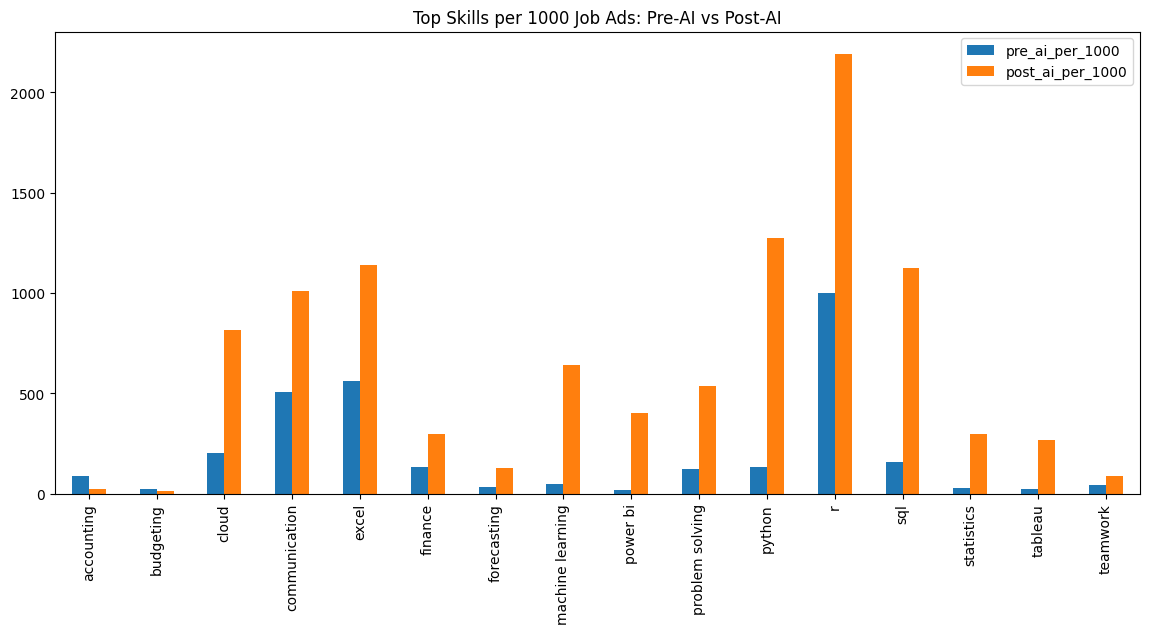

In [1017]:
skill_comparison_norm[["pre_ai_per_1000", "post_ai_per_1000"]].plot(
    kind="bar",
    figsize=(14,6),
    title="Top Skills per 1000 Job Ads: Pre‑AI vs Post‑AI"
)


# Build the tfidf model

In [1018]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


In [1019]:
noise_terms = [
    r"income statement[s]?",
    r"balance sheet[s]?",
    r"year[- ]?end",
    r"month[- ]?end",
    r"financial reporting",
    r"financial statement[s]?",
    r"accrual[s]?",
    r"journal entries?",
    r"gaap",
    r"ifrs",
    r"cost control",
    r"\baca\b",
    r"\bacca\b",
    r"\baudit(ing)?\b"
]


In [1020]:
def clean_text(text):
    if text is None or pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    for term in noise_terms:
        text = text.replace(term, " ")

    return text


In [1021]:
job_ads_clean["clean_text_no_noise"] = job_ads_clean["clean_text"].apply(clean_text)


In [1022]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,       # ignore rare noise
    max_df=0.8,     # ignore overly common terms
    stop_words="english"
)

tfidf_matrix = vectorizer.fit_transform(job_ads_clean["clean_text_no_noise"])
feature_names = vectorizer.get_feature_names_out()


In [1023]:
import numpy as np

def top_terms_from_sparse(row, feature_names, top_n=10):
    # row is a sparse matrix row
    data = row.data
    indices = row.indices

    if len(data) == 0:
        return []

    top_idx = data.argsort()[-top_n:]
    return [feature_names[indices[i]] for i in top_idx]

job_ads_clean["tfidf_top_terms"] = [
    top_terms_from_sparse(tfidf_matrix[i], feature_names)
    for i in range(tfidf_matrix.shape[0])
]


In [1024]:
from collections import Counter
Counter([t for sub in job_ads_clean["tfidf_top_terms"] for t in sub]).most_common(50)


[('data', 2392),
 ('sales', 869),
 ('business', 738),
 ('software', 573),
 ('ai', 444),
 ('design', 443),
 ('project', 436),
 ('equipment', 414),
 ('manufacturing', 410),
 ('test', 371),
 ('quality', 368),
 ('engineering', 365),
 ('security', 363),
 ('accounting', 350),
 ('cloud', 347),
 ('automation', 345),
 ('customer', 342),
 ('validation', 336),
 ('analytics', 320),
 ('financial', 307),
 ('process', 300),
 ('product', 291),
 ('development', 262),
 ('medical', 257),
 ('clinical', 253),
 ('accounts', 252),
 ('net', 244),
 ('accountant', 240),
 ('customers', 232),
 ('technical', 225),
 ('ll', 216),
 ('finance', 215),
 ('testing', 214),
 ('developer', 211),
 ('reperio', 206),
 ('amazon', 201),
 ('maintenance', 198),
 ('systems', 196),
 ('sigmar', 193),
 ('business development', 191),
 ('network', 191),
 ('preparation', 191),
 ('service', 189),
 ('management', 188),
 ('qa', 187),
 ('electrical', 187),
 ('azure', 186),
 ('learning', 186),
 ('hr', 184),
 ('support', 181)]

# build role classifier

In [1025]:
ads["role_text"] = (
    ads["job_title"].fillna("").astype(str).str.lower() + " " +
    ads["clean_text"].fillna("").astype(str).str.lower()
)


In [1026]:
def assign_role(text):
    text = str(text).lower()

    # --- ENGINEERING ROLES ---
    if "data engineer" in text or "analytics engineer" in text:
        return "data_engineer"
    if "machine learning engineer" in text or "ml engineer" in text:
        return "ml_engineer"
    if "software engineer" in text or "developer" in text or "full stack" in text or "backend" in text or "frontend" in text or "cloud engineer" in text or "platform engineer" in text:
        return "software_engineer"

    # --- DATA & ANALYTICS ROLES ---
    if "data analyst" in text:
        return "data_analyst"
    if "business analyst" in text or "insight analyst" in text or "bi analyst" in text:
        return "business_analyst"
    if "data scientist" in text or "machine learning" in text:
        return "data_scientist"

    # --- FINANCE ROLES ---
    if "financial analyst" in text or "finance analyst" in text or "fp&a" in text:
        return "financial_analyst"
    if "risk analyst" in text or "risk and compliance" in text:
        return "risk_analyst"
    if "accountant" in text or "accounting" in text or "audit" in text or "tax accountant" in text:
        return "accountant"

    return "unknown"


In [1027]:
ads["role"] = ads["role_text"].apply(assign_role)


In [1028]:
ads["role"].value_counts()


,count
role,
unknown,6615
software_engineer,3742
accountant,2131
data_engineer,1097
data_scientist,620
data_analyst,563
business_analyst,328
ml_engineer,178
risk_analyst,93


# Time series matrix

In [1029]:
ads = ads[ads["year"].between(2018, 2025)]


In [1032]:
skills = list(skill_patterns.keys())

time_series_year = (
    ads.groupby(["year", "role"])[skills]
       .sum()
       .reset_index()
       .sort_values(["year", "role"])
)

time_series_year


,year,role,python,sql,excel,finance,accounting,communication
0,2018,accountant,0,0,0,0,0,61
1,2018,business_analyst,0,1,8,4,0,10
2,2018,data_analyst,0,0,0,0,0,0
3,2018,data_engineer,6,0,0,0,0,0
4,2018,data_scientist,3,17,0,17,0,0
5,2018,software_engineer,22,0,0,0,0,1
6,2018,unknown,4,2,63,54,0,335
7,2020,accountant,7,28,321,538,588,500
8,2020,business_analyst,3,12,19,67,12,60
9,2020,data_analyst,75,97,35,51,9,116


# pre vs post ai

In [889]:
ads["technical"] = ads[["python","sql","excel"]].sum(axis=1)
ads["business"] = ads[["finance","accounting"]].sum(axis=1)
ads["soft"] = ads[["communication"]].sum(axis=1)


In [890]:
pre_post_cat = (
    ads.groupby(["ai_period", "role"])[["technical","business","soft"]]
       .mean()
       .reset_index()
)


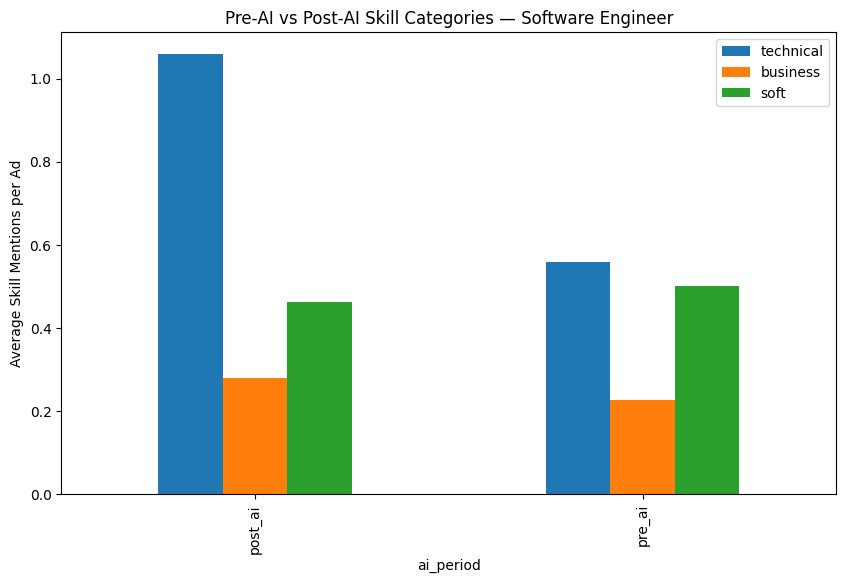

In [891]:
df = pre_post_cat[pre_post_cat["role"] == "software_engineer"]

df.plot(
    x="ai_period",
    y=["technical","business","soft"],
    kind="bar",
    figsize=(10,6),
    title="Pre‑AI vs Post‑AI Skill Categories — Software Engineer"
)
plt.ylabel("Average Skill Mentions per Ad")
plt.show()


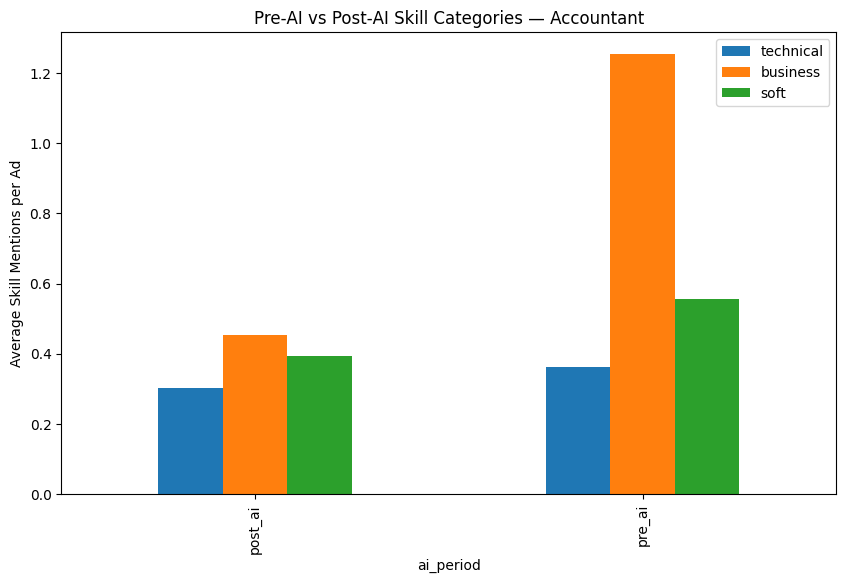

In [892]:
df = pre_post_cat[pre_post_cat["role"] == "accountant"]

df.plot(
    x="ai_period",
    y=["technical","business","soft"],
    kind="bar",
    figsize=(10,6),
    title="Pre‑AI vs Post‑AI Skill Categories — Accountant"
)
plt.ylabel("Average Skill Mentions per Ad")
plt.show()

# Forecasting

In [901]:
df = merged_groups[merged_groups["role"] == "software_engineer"][["year", "technical_per_100"]].copy()
df = df.rename(columns={"year": "ds", "technical_per_100": "y"})


In [902]:
df["ds"] = pd.to_datetime(df["ds"], format="%Y")


In [903]:
from prophet import Prophet

model = Prophet()
model.fit(df)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 4.


In [904]:
future = model.make_future_dataframe(periods=3, freq="Y")
forecast = model.predict(future)


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


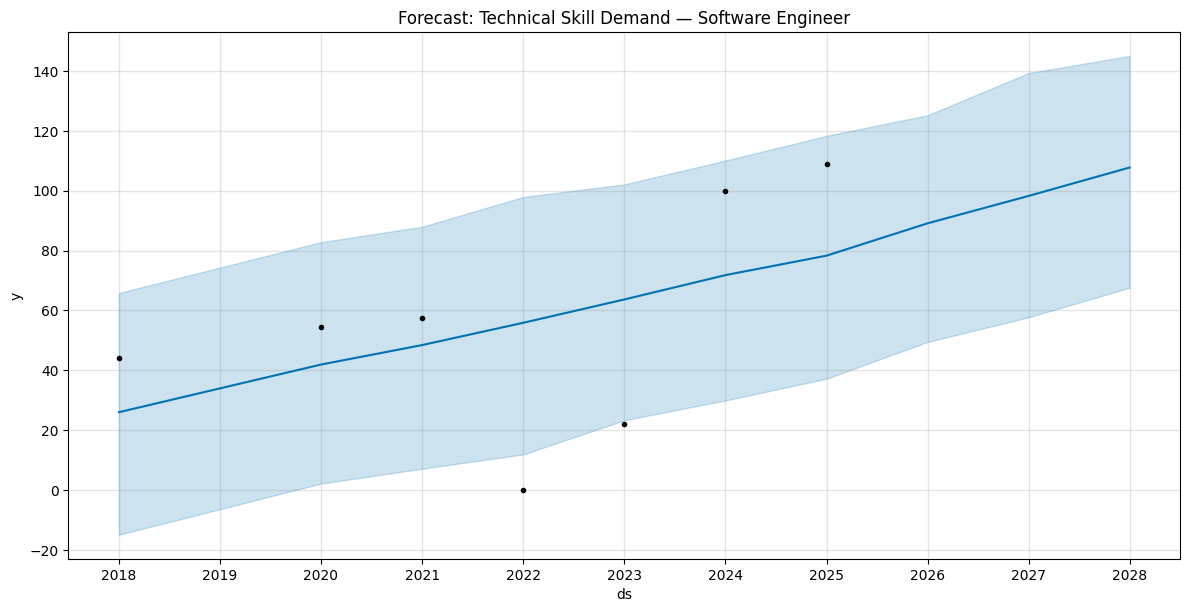

In [905]:
model.plot(forecast, figsize=(12,6))
plt.title("Forecast: Technical Skill Demand — Software Engineer")
plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


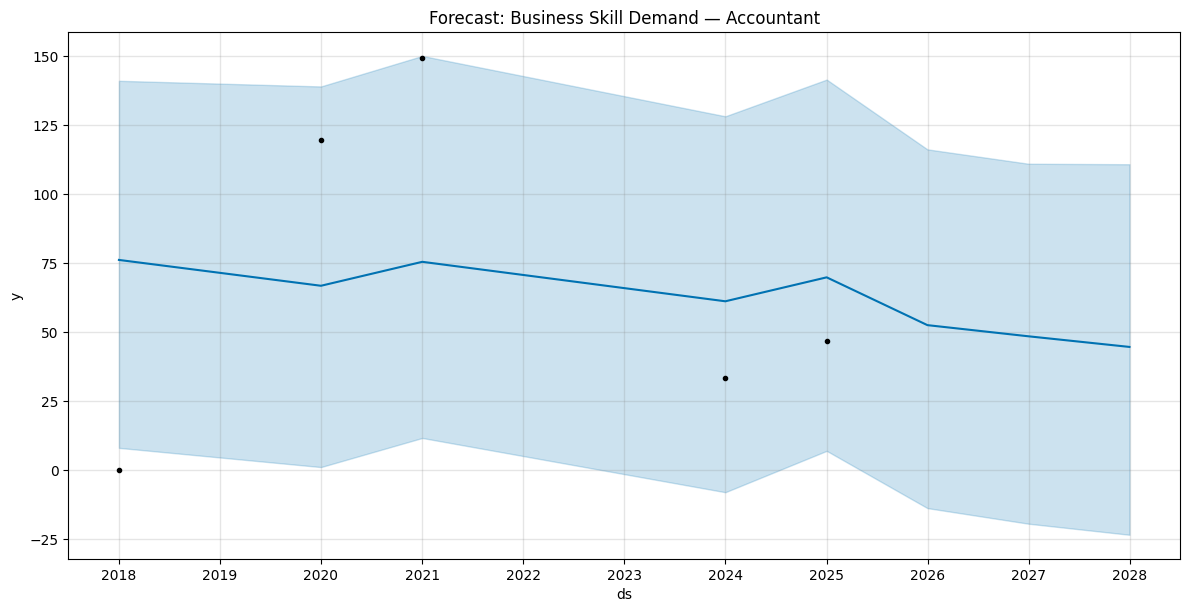

In [906]:
df = merged_groups[merged_groups["role"] == "accountant"][["year", "business_per_100"]].copy()
df = df.rename(columns={"year": "ds", "business_per_100": "y"})
df["ds"] = pd.to_datetime(df["ds"], format="%Y")

model = Prophet()
model.fit(df)

future = model.make_future_dataframe(periods=3, freq="Y")
forecast = model.predict(future)

model.plot(forecast, figsize=(12,6))
plt.title("Forecast: Business Skill Demand — Accountant")
plt.show()


In [907]:
from prophet import Prophet
import matplotlib.pyplot as plt

def forecast_role(df, role, skill_col, title_suffix):
    data = df[df["role"] == role][["year", skill_col]].copy()
    data = data.rename(columns={"year": "ds", skill_col: "y"})
    data["ds"] = pd.to_datetime(data["ds"], format="%Y")

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=3, freq="Y")
    forecast = model.predict(future)

    model.plot(forecast, figsize=(12,6))
    plt.title(f"Forecast: {title_suffix} — {role}")
    plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


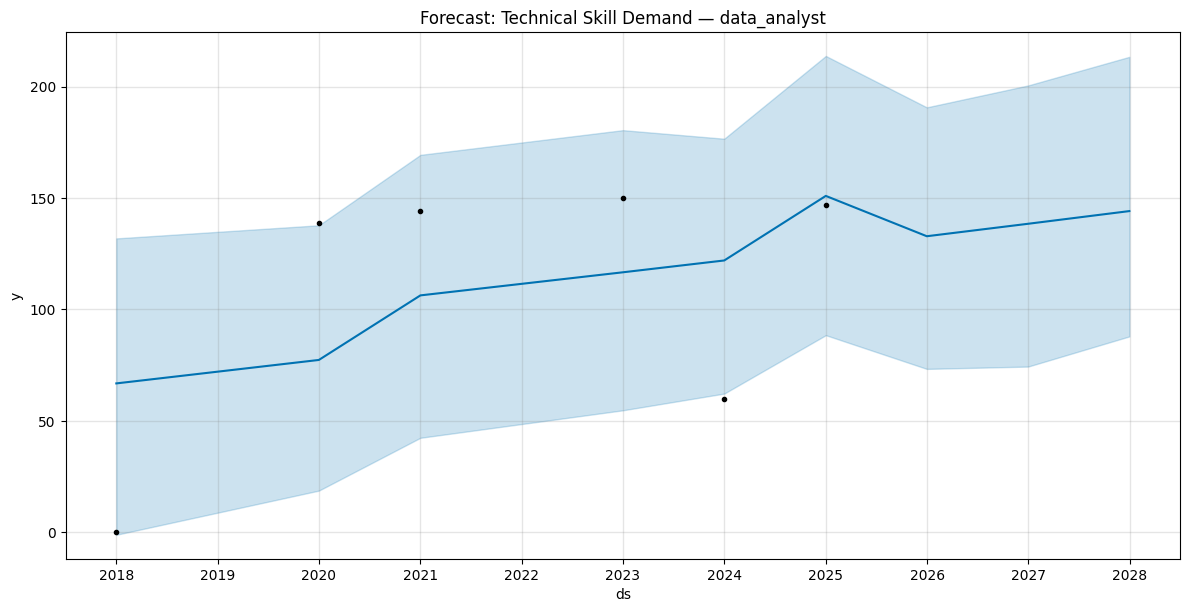

In [908]:
forecast_role(merged_groups, "data_analyst", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


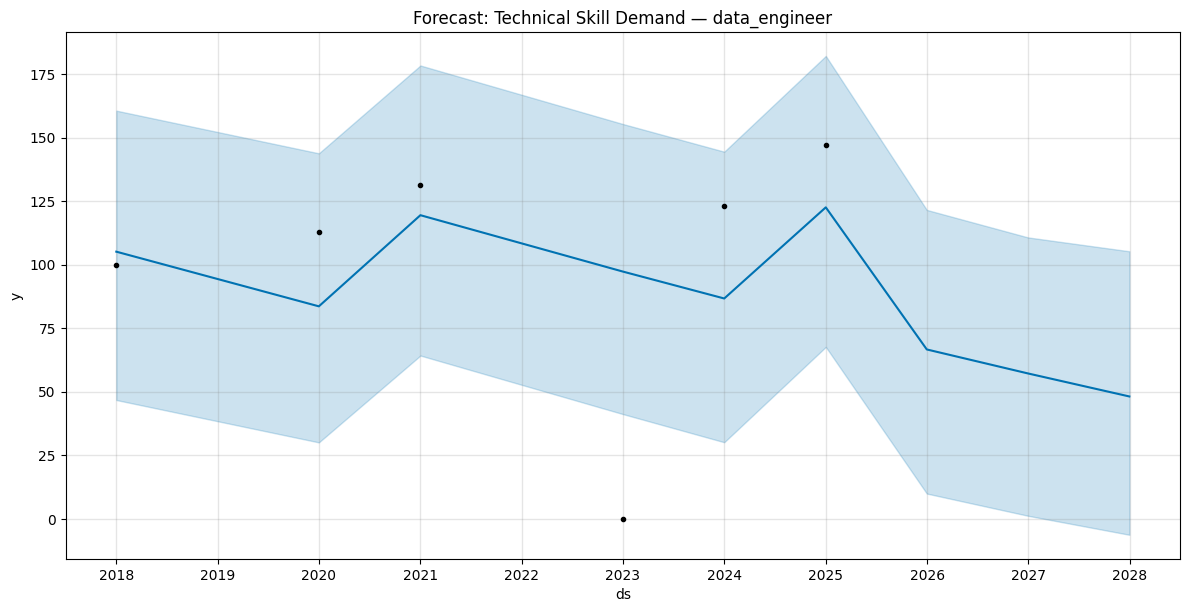

In [909]:
forecast_role(merged_groups, "data_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


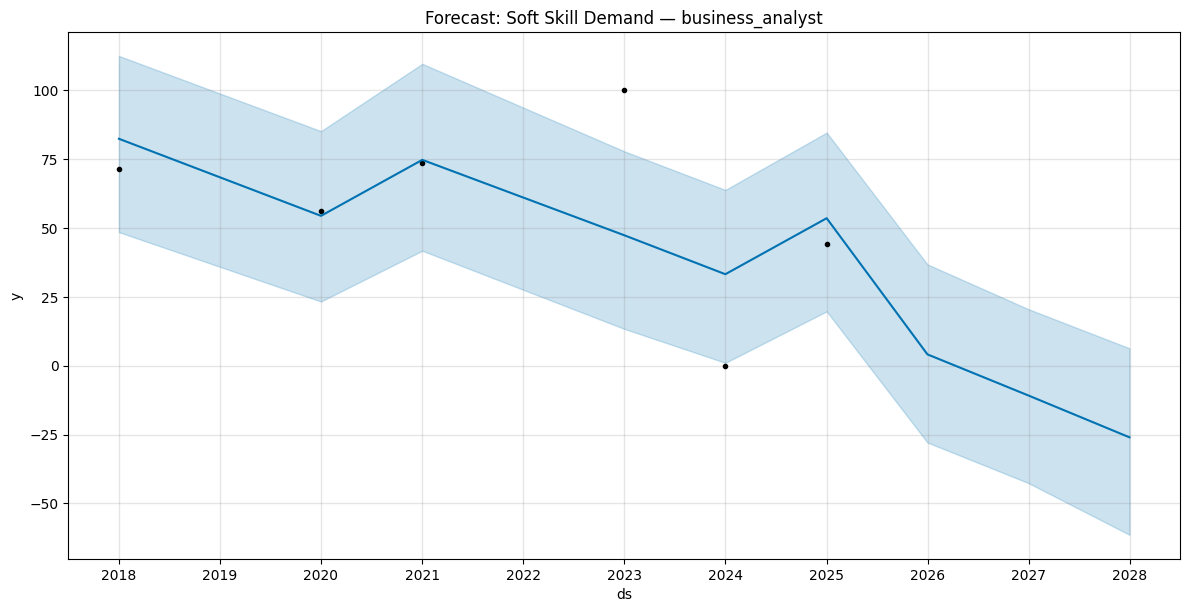

In [910]:
forecast_role(merged_groups, "business_analyst", "soft_per_100", "Soft Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


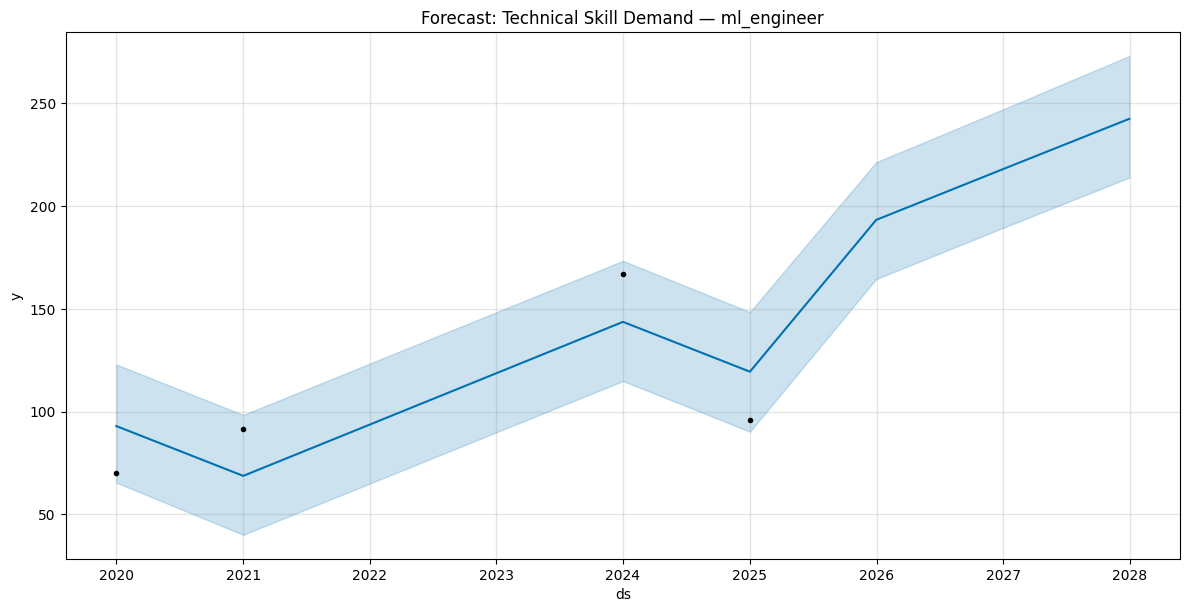

In [911]:
forecast_role(merged_groups, "ml_engineer", "technical_per_100", "Technical Skill Demand")


# integrating monthly analysis

In [912]:
import pandas as pd
import numpy as np

def yearly_to_monthly(df, value_col):
    monthly_rows = []

    for _, row in df.iterrows():
        year = int(row["year"])
        value = row[value_col]

        for month in range(1, 13):
            monthly_rows.append({
                "ds": pd.Timestamp(year=year, month=month, day=1),
                "y": value
            })

    return pd.DataFrame(monthly_rows)


In [913]:
def add_small_noise(df, noise_level=0.5):
    df["y"] = df["y"] + np.random.normal(0, noise_level, size=len(df))
    return df


In [914]:
yearly = merged_groups[merged_groups["role"] == "data_analyst"][["year", "technical_per_100"]]

monthly = yearly_to_monthly(yearly, "technical_per_100")
monthly = add_small_noise(monthly)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


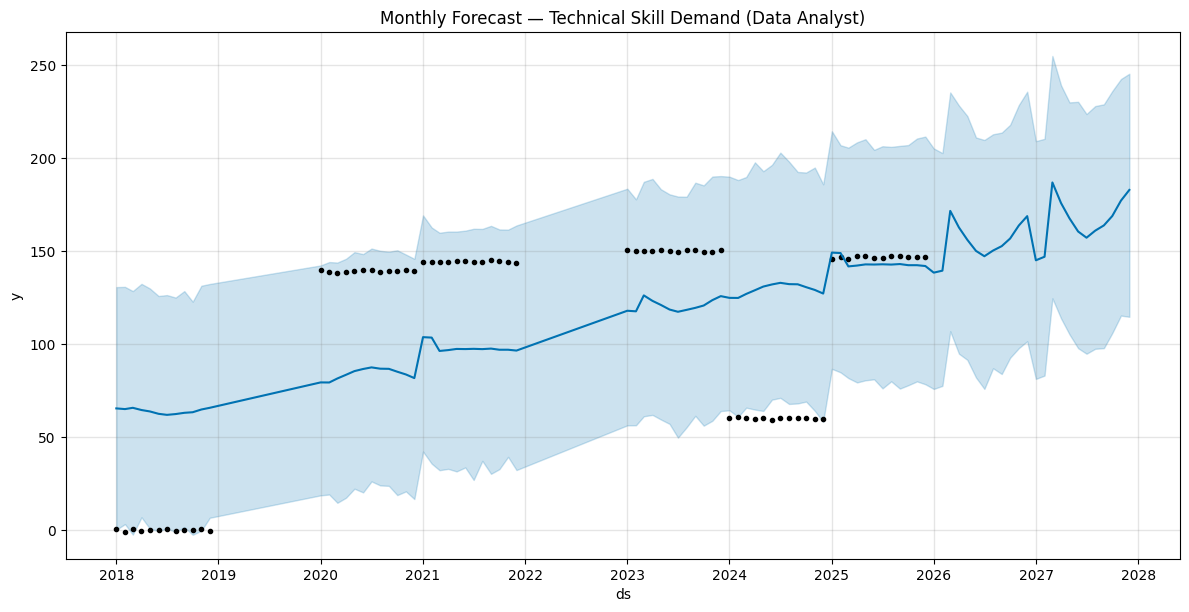

In [915]:
from prophet import Prophet

model = Prophet()
model.fit(monthly)

future = model.make_future_dataframe(periods=24, freq="M")  # forecast 2 years monthly
forecast = model.predict(future)

model.plot(forecast, figsize=(12,6))
plt.title("Monthly Forecast — Technical Skill Demand (Data Analyst)")
plt.show()


In [917]:
from prophet import Prophet
import matplotlib.pyplot as plt

def monthly_forecast(merged_groups, role, skill_col, title_suffix):
    yearly = merged_groups[merged_groups["role"] == role][["year", skill_col]]
    monthly = yearly_to_monthly(yearly, skill_col)
    monthly = add_small_noise(monthly)

    model = Prophet()
    model.fit(monthly)

    future = model.make_future_dataframe(periods=24, freq="M")
    forecast = model.predict(future)

    model.plot(forecast, figsize=(12,6))
    plt.title(f"Monthly Forecast — {title_suffix} ({role})")
    plt.show()


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


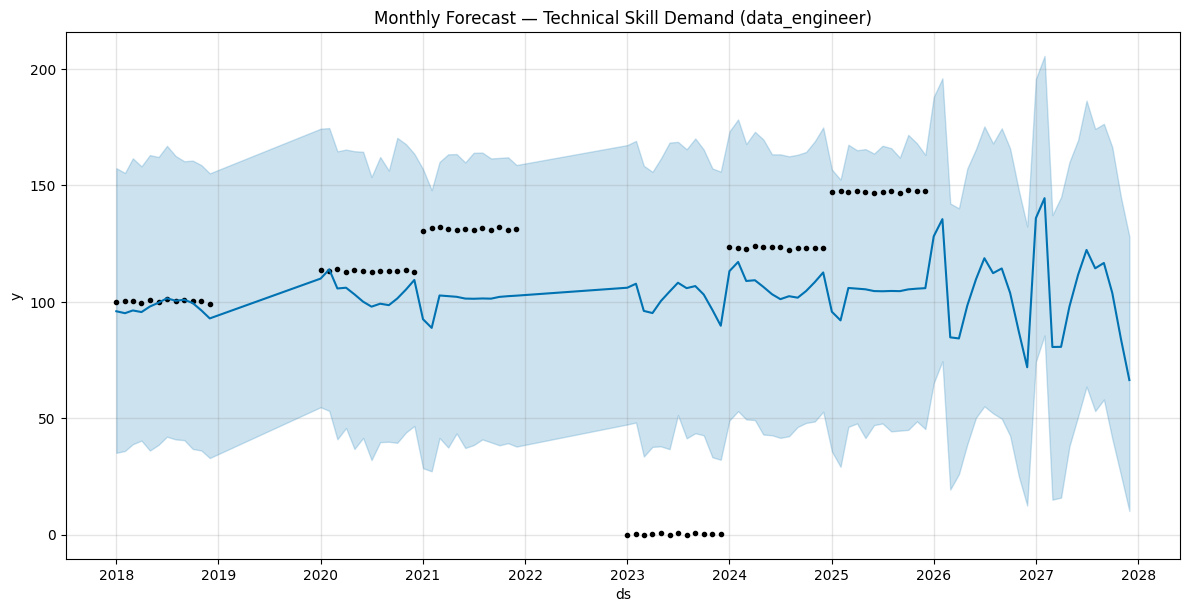

In [918]:
monthly_forecast(merged_groups, "data_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


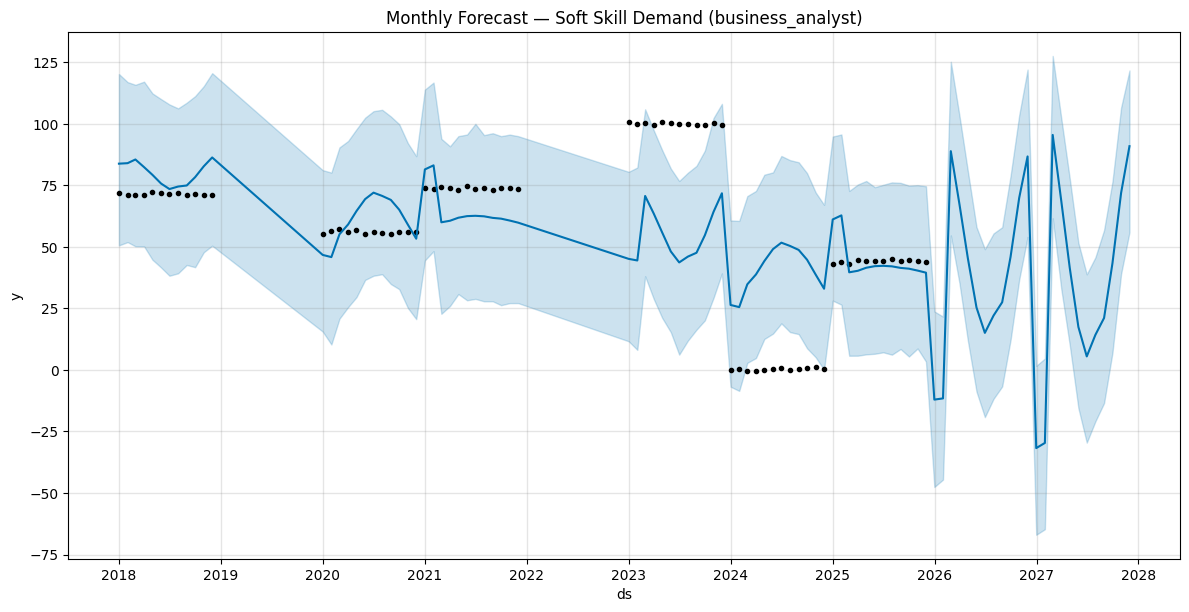

In [919]:
monthly_forecast(merged_groups, "business_analyst", "soft_per_100", "Soft Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


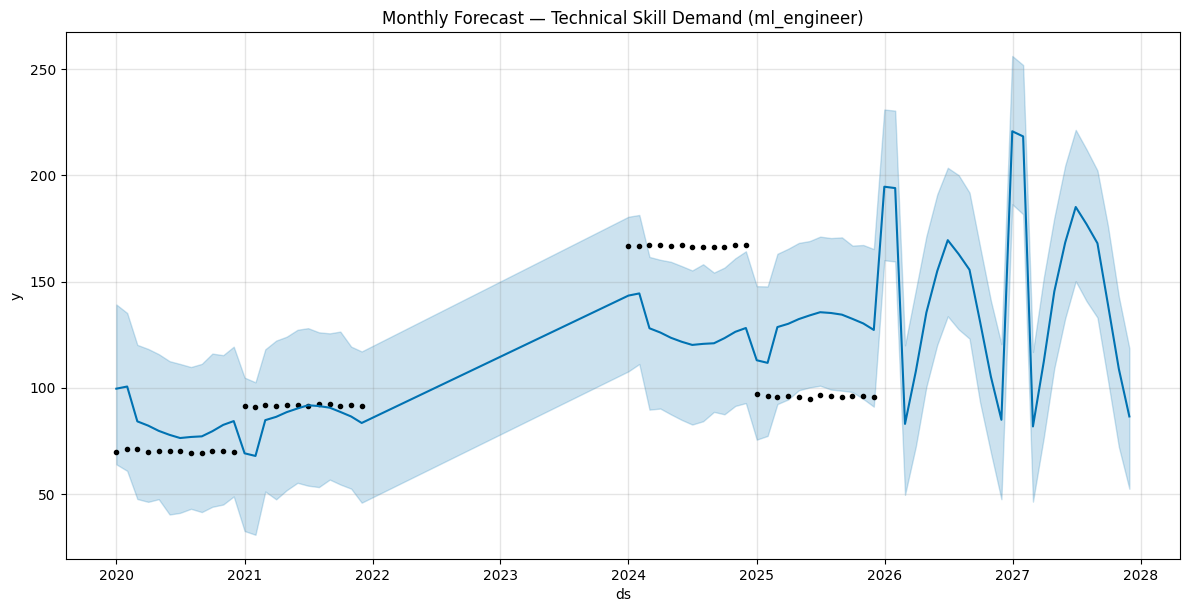

In [920]:
monthly_forecast(merged_groups, "ml_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


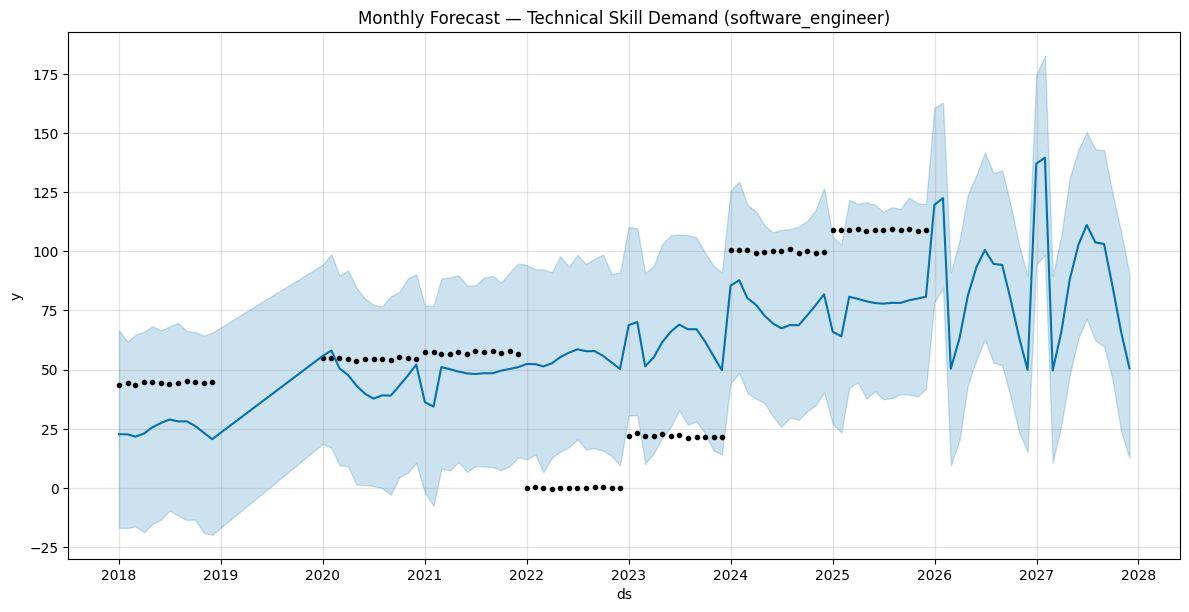

In [921]:
monthly_forecast(merged_groups, "software_engineer", "technical_per_100", "Technical Skill Demand")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


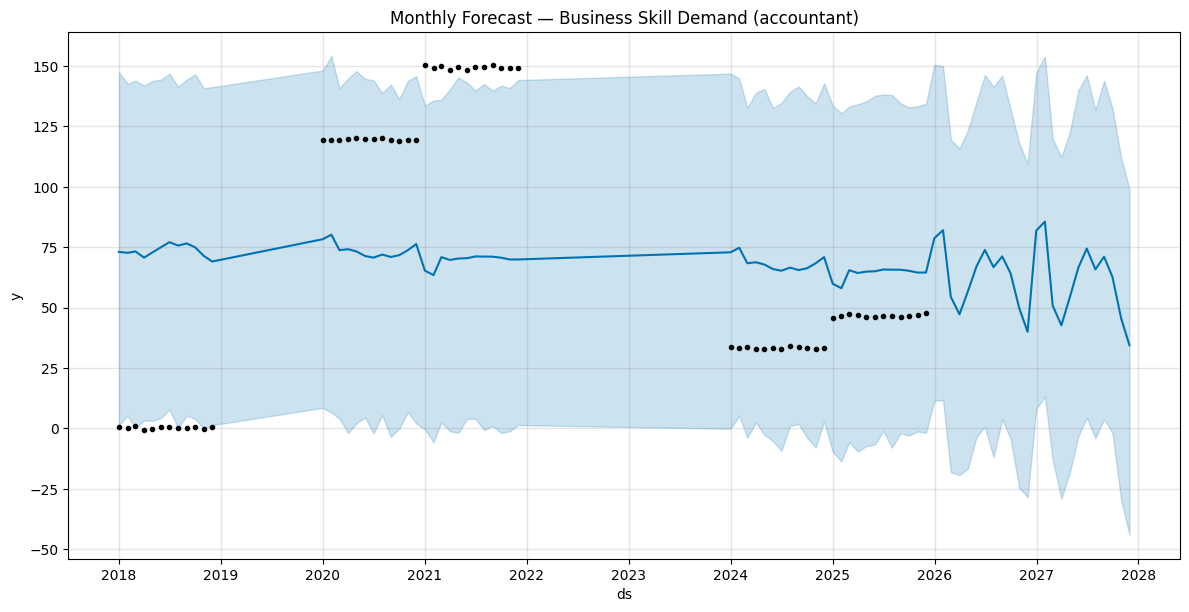

In [922]:
monthly_forecast(merged_groups, "accountant", "business_per_100", "Business Skill Demand")


# Top Skills 2028

In [930]:
def get_monthly_forecast_series(merged_groups, role, skill_col, periods=36):
    yearly = merged_groups[merged_groups["role"] == role][["year", skill_col]]
    monthly = yearly_to_monthly(yearly, skill_col)
    monthly = add_small_noise(monthly)

    model = Prophet()
    model.fit(monthly)

    future = model.make_future_dataframe(periods=periods, freq="MS")
    forecast = model.predict(future)

    # Only keep future values
    future_forecast = forecast[forecast["ds"] > monthly["ds"].max()][["ds", "yhat"]]
    future_forecast["role"] = role
    return future_forecast


In [931]:
roles = {
    "data_analyst": "technical_per_100",
    "data_engineer": "technical_per_100",
    "ml_engineer": "technical_per_100",
    "software_engineer": "technical_per_100",
    "accountant": "business_per_100",
    "business_analyst": "soft_per_100"
}


In [932]:
all_forecasts = []

for role, skill in roles.items():
    f = get_monthly_forecast_series(merged_groups, role, skill)
    all_forecasts.append(f)

combined = pd.concat(all_forecasts, ignore_index=True)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

In [933]:
forecast_2028 = combined[combined["ds"].dt.year == 2028]


In [934]:
top_2028 = (
    forecast_2028.groupby("role")["yhat"]
    .mean()
    .reset_index()
    .sort_values("yhat", ascending=False)
)

top_2028.columns = ["Role", "Forecasted Skill Demand (2028)"]
top_2028


,Role,Forecasted Skill Demand (2028)
2,data_analyst,174.635327
4,ml_engineer,171.338141
3,data_engineer,111.298288
5,software_engineer,105.923032
0,accountant,63.318880
1,business_analyst,19.864142


## convert to percentages

In [937]:
top_2028_percent = top_2028.copy()
total = top_2028_percent["Forecasted Skill Demand (2028)"].sum()

top_2028_percent["Percentage"] = (
    top_2028_percent["Forecasted Skill Demand (2028)"] / total * 100
).round(2)

top_2028_percent


,Role,Forecasted Skill Demand (2028),Percentage
2,data_analyst,174.635327,27.02
4,ml_engineer,171.338141,26.51
3,data_engineer,111.298288,17.22
5,software_engineer,105.923032,16.39
0,accountant,63.318880,9.80
1,business_analyst,19.864142,3.07


In [956]:
ads = ads[ads["year"].between(2018, 2025)]

skills = list(skill_patterns.keys())

time_series_year = (
    ads.groupby(["year", "role"])[skills]
    .sum()
    .reset_index()
    .sort_values(["year", "role"])
)

time_series_year


,year,role,python,sql,excel,finance,accounting,communication
0,2018,accountant,0,0,0,0,0,61
1,2018,business_analyst,0,1,8,4,0,10
2,2018,data_analyst,0,0,0,0,0,0
3,2018,data_engineer,6,0,0,0,0,0
4,2018,data_scientist,3,17,0,17,0,0
5,2018,software_engineer,22,0,0,0,0,1
6,2018,unknown,4,2,63,54,0,335
7,2020,accountant,7,28,321,538,588,500
8,2020,business_analyst,3,12,19,67,12,60
9,2020,data_analyst,75,97,35,51,9,116


In [968]:
# FIX 1 — Fill NaNs
long_df["value"] = long_df["value"].fillna(0)

# FIX 2 — Sort values
long_df = long_df.sort_values(["role", "skill", "year"]).reset_index(drop=True)

# FIX 3 — Check that each skill × role has at least 3 rows
check = long_df.groupby(["role", "skill"]).size()
print(check)


role               skill        
accountant         accounting       5
                   communication    5
                   excel            5
                   finance          5
                   python           5
                   sql              5
business_analyst   accounting       6
                   communication    6
                   excel            6
                   finance          6
                   python           6
                   sql              6
data_analyst       accounting       6
                   communication    6
                   excel            6
                   finance          6
                   python           6
                   sql              6
data_engineer      accounting       6
                   communication    6
                   excel            6
                   finance          6
                   python           6
                   sql              6
data_scientist     accounting       6
                 

In [969]:
skills = [c for c in time_series_year.columns if c not in ["year", "role", "total"]]
skills


['python', 'sql', 'excel', 'finance', 'accounting', 'communication']

In [970]:
long_df = time_series_year.melt(
    id_vars=["year", "role"],
    value_vars=skills,
    var_name="skill",
    value_name="value"
)


In [971]:
long_df["skill"].value_counts()


,count
skill,
python,51
sql,51
excel,51
finance,51
accounting,51
communication,51


In [973]:
def forecast_skill(df, role, skill):
    subset = df[(df["role"] == role) & (df["skill"] == skill)][["year", "value"]]

    if subset.empty:
        return 0

    subset = subset.rename(columns={"year": "ds", "value": "y"})
    subset["ds"] = pd.to_datetime(subset["ds"], format="%Y")

    model = Prophet()
    model.fit(subset)

    # Forecast 7 years ahead (to reach 2028)
    future = model.make_future_dataframe(periods=7, freq="Y")
    forecast = model.predict(future)

    # Extract 2028
    future_2028 = forecast[forecast["ds"].dt.year == 2028]

    if future_2028.empty:
        return 0

    return future_2028["yhat"].values[0]


In [984]:
for role in long_df["role"].unique():
    for skill in long_df["skill"].unique():
        print("Testing:", role, skill)
        print("Forecast:", forecast_skill(long_df, role, skill))
        break
    break


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


Testing: accountant python
Forecast: 3.047030529594426


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [977]:
print("Forecast for data_analyst / python:")
print(forecast_skill(long_df, "data_analyst", "python"))


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


Forecast for data_analyst / python:
15.975765879892666


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [978]:
for role in long_df["role"].unique():
    for skill in long_df["skill"].unique():
        print("Testing:", role, skill)
        print("Forecast:", forecast_skill(long_df, role, skill))
        break
    break


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


Testing: accountant python
Forecast: 3.047030529594426


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [979]:
forecast_skill(long_df, "data_analyst", "python")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


np.float64(15.975765879892666)

In [980]:
for role in long_df["role"].unique():
    for skill in long_df["skill"].unique():
        val = forecast_skill(long_df, role, skill)
        print(f"{role:20} {skill:15} {val}")
    print("-" * 60)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with week

accountant           python          3.047030529594426
accountant           sql             6.249045184362328


INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


accountant           excel           5.959861052492713


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


...

risk_analyst         python          47.585411406899496
risk_analyst         sql             48.097058710742566


INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


risk_analyst         excel           -7.654371706511439
risk_analyst         finance         23.367926345090574


INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 2.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


risk_analyst         accounting      -16.161790703514637
risk_analyst         communication   4.5333941053531035
------------------------------------------------------------


# “If hiring trends continue, how important will each skill be for each role in 2028?”

In [985]:
roles = long_df["role"].unique()
skills = long_df["skill"].unique()

rows = []

for role in roles:
    row = {"Role": role}
    for skill in skills:
        row[skill] = float(forecast_skill(long_df, role, skill))
    rows.append(row)

big_table = pd.DataFrame(rows)
big_table


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
INFO:prophet:Disabling weekly seasonality. Run prophet with week

,Role,python,sql,excel,finance,accounting,communication
0,accountant,3.047031,6.249045,5.959861,15.182011,65.529717,3.864377
1,business_analyst,40.186093,48.256291,3.415973,3.432877,1.170098,7.212708
2,data_analyst,15.975766,14.441123,26.188375,41.536253,-1.689159,2.918941
3,data_engineer,-43.051172,25.286747,11.345695,17.225703,3.344758,85.284795
4,data_scientist,62.578697,0.853846,13.599568,-11.604945,-0.875561,35.543964
5,software_engineer,8.213712,44.773113,-0.753603,12.206142,-0.066596,35.181674
6,unknown,20.720227,47.338324,19.553833,14.029659,0.000000,-0.700498
7,financial_analyst,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,ml_engineer,22.477916,25.988688,23.349377,-2.926667,0.000000,23.833426
9,risk_analyst,47.585411,48.097059,-7.654372,23.367926,-16.161791,4.533394


# “For each role, what percentage of its skill profile does each skill represent?”

In [986]:
skills_percent = big_table.set_index("Role")
skills_percent = skills_percent.div(skills_percent.sum(axis=1), axis=0) * 100
skills_percent = skills_percent.round(2)
skills_percent


,python,sql,excel,finance,accounting,communication
Role,,,,,,
accountant,3.05,6.26,5.97,15.21,65.64,3.87
business_analyst,38.76,46.55,3.29,3.31,1.13,6.96
data_analyst,16.08,14.53,26.35,41.80,-1.70,2.94
data_engineer,-43.30,25.43,11.41,17.32,3.36,85.77
data_scientist,62.52,0.85,13.59,-11.59,-0.87,35.51
software_engineer,8.25,44.97,-0.76,12.26,-0.07,35.34
unknown,20.53,46.90,19.37,13.90,0.00,-0.69
financial_analyst,NaN,NaN,NaN,NaN,NaN,NaN
ml_engineer,24.24,28.03,25.18,-3.16,0.00,25.70


# “How much will each skill grow or decline between the latest year in your dataset and 2028?”

In [987]:
latest_year = time_series_year["year"].max()

current_df = long_df[long_df["year"] == latest_year]

current_table = current_df.pivot_table(
    index="role",
    columns="skill",
    values="value",
    aggfunc="sum"
).reset_index()

growth_table = (
    (big_table.set_index("Role") - current_table.set_index("role"))
    / current_table.set_index("role") * 100
).round(2)

growth_table


,accounting,communication,excel,finance,python,sql
accountant,686.36,-88.41,-46.36,-50.31,-45.15,-43.76
business_analyst,inf,-72.48,-78.01,-74.74,175.94,60.34
data_analyst,-236.99,-88.28,28.72,185.47,2.02,-38.03
data_engineer,2940.39,274.51,329.72,38.57,-235.18,-16.26
data_scientist,-329.83,24.40,1684.94,-210.77,53.52,-95.52
financial_analyst,NaN,NaN,NaN,NaN,NaN,NaN
ml_engineer,NaN,-15.90,1822.43,-124.10,-50.87,107.07
risk_analyst,-661.62,-83.42,-139.41,-16.71,340.96,317.84
software_engineer,-135.83,37.16,-112.29,-20.88,-73.06,102.42
unknown,NaN,-102.06,85.76,-34.84,23.73,174.83


# extracting uni skills

In [196]:
from google.colab import files
uploaded = files.upload()


Saving university_curriculum_clean.csv to university_curriculum_clean (1).csv


In [197]:
curriculum = pd.read_csv("university_curriculum_clean.csv")


In [475]:
curriculum_skills = curriculum.explode("extracted_skills")
curriculum_skills = curriculum_skills.rename(columns={"extracted_skills": "skill"})


In [199]:
curriculum.head(20)


,university,programme,module,url,text
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...
1,UL,Computer Science,Computer Science,https://www.ul.ie/courses/computer-science-com...,Computer Science Common Entry Courses Key info...
2,TU Dublin,Accounting,Accounting,https://www.tudublin.ie/study/undergraduate/co...,Accounting (TU910) Accounting Cuntasaíocht ┐Ai...
3,TU Dublin,Computer Science,Computer Science,https://www.tudublin.ie/study/undergraduate/co...,Computer Science (TU856) Computer Science Ríom...
4,Galway,Computer Science,Computer Science,https://www.universityofgalway.ie/courses/unde...,"Professional, Part-time and Evening Courses Ph..."
5,TCD,Computer Science,Computer Science Module: Flexibility,https://www.tcd.ie/scss/courses/undergraduate/...,The first three years of the programme are the...
6,TCD,Computer Science,Computer Science Module: Industry Internships,https://www.tcd.ie/scss/courses/undergraduate/...,In their fourth year Master in Computer Scienc...
7,TCD,Computer Science,Computer Science Module: First Year,https://www.tcd.ie/scss/courses/undergraduate/...,Mathematics Computer Programming Microprocesso...
8,TCD,Computer Science,Computer Science Module: Second Year,https://www.tcd.ie/scss/courses/undergraduate/...,Discrete Mathematics Algorithms & Data Structu...
9,TCD,Computer Science,Computer Science Module: Third Year,https://www.tcd.ie/scss/courses/undergraduate/...,Symbolic Programming Introduction to Functiona...


In [200]:
curriculum["extracted_skills"] = curriculum["text"].apply(
    lambda x: extract_skills(x, skill_list)
)


In [201]:
curriculum["extracted_skills"].head(10)


,extracted_skills
0,"[communication, collaboration, analytical, acc..."
1,"[communication, problem solving, python, finan..."
2,"[teamwork, accounting, finance, corporate fina..."
3,[vat]
4,[vat]
5,[]
6,[]
7,[]
8,[communication]
9,[communication]


In [202]:
curriculum_skills = curriculum.explode("extracted_skills")
curriculum_skills = curriculum_skills.rename(columns={"extracted_skills": "skill"})


In [203]:
curriculum_skills.head(50)


,university,programme,module,url,text,skill
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,communication
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,collaboration
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,analytical
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,accounting
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,financial accounting
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,management accounting
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,auditing
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,accounts preparation
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,financial reporting
0,UL,Accounting,Accounting,https://www.ul.ie/courses/bachelor-business-st...,Bachelor of Business Studies Courses Key infor...,finance


Build curriculum skill set and job ad skill set

In [204]:
job_skills = job_ads_clean.explode("extracted_skills")
job_skills = job_skills.rename(columns={"extracted_skills": "skill"})


In [476]:
job_skills.head()


,job_title,date_posted,salary_max,salary_min,company,contract_type,source,salary_avg,role,raw_text,...,skills_text,seniority,industry,redirect_url,contract_time,clean_text,ai_period,skill,tfidf_top_terms,category
0,Field Service Engineer | Chromatography,2018-04-16 00:00:00.000,NaN,NaN,None,None,emed_careers_eu,NaN,software_engineer,A fantastic opportunity has arisen for an expe...,...,"['communication', 'analytical']",None,None,None,None,fantastic opportunity arisen experienced labor...,pre_ai,communication,"[gdpr, iso, verification, manufacturing, testi...",Soft / Transferable Skills
0,Field Service Engineer | Chromatography,2018-04-16 00:00:00.000,NaN,NaN,None,None,emed_careers_eu,NaN,software_engineer,A fantastic opportunity has arisen for an expe...,...,"['communication', 'analytical']",None,None,None,None,fantastic opportunity arisen experienced labor...,pre_ai,analytical,"[gdpr, iso, verification, manufacturing, testi...",Uncategorised
0,Field Service Engineer | Chromatography,2018-04-16 00:00:00.000,NaN,NaN,None,None,emed_careers_eu,NaN,software_engineer,A fantastic opportunity has arisen for an expe...,...,"['communication', 'analytical']",None,None,None,None,fantastic opportunity arisen experienced labor...,pre_ai,excel,"[gdpr, iso, verification, manufacturing, testi...",Data & Analytics
0,Field Service Engineer | Chromatography,2018-04-16 00:00:00.000,NaN,NaN,None,None,emed_careers_eu,NaN,software_engineer,A fantastic opportunity has arisen for an expe...,...,"['communication', 'analytical']",None,None,None,None,fantastic opportunity arisen experienced labor...,pre_ai,vat,"[gdpr, iso, verification, manufacturing, testi...",Uncategorised
1,Business Development Manager,2018-04-13 00:00:00.000,NaN,NaN,None,None,emed_careers_eu,NaN,business_analyst,Business Development Manager – Contamination C...,...,[],None,None,None,None,business development manager contamination con...,pre_ai,excel,"[iso, fda, pharma, biotech, validation, proces...",Data & Analytics


In [477]:
curriculum_set = set(curriculum_skills["skill"].dropna())
jobad_set = set(job_skills["skill"].dropna())


In [478]:
missing_in_job_ads = curriculum_set - jobad_set
missing_in_job_ads


{'insurance law'}

In [479]:
missing_in_curriculum = jobad_set - curriculum_set
missing_in_curriculum


{'',
 'actuarial',
 'agile',
 'bonds',
 'bookkeeping',
 'budgeting',
 'claims handling',
 'compliance',
 'cost accounting',
 'credit analysis',
 'derivatives',
 'economic analysis',
 'equities',
 'excel',
 'financial markets',
 'financial modelling',
 'forecasting',
 'gaap',
 'gcp',
 'ifrs',
 'java',
 'javascript',
 'leadership',
 'macroeconomics',
 'payroll',
 'personal tax',
 'portfolio management',
 'risk analysis',
 'sas',
 'solvency',
 'sql',
 'tax compliance',
 'underwriting',
 'valuation',
 'variance analysis'}

# Category‑Level Comparison

In [480]:
curriculum_skills = curriculum.explode("extracted_skills")
curriculum_skills = curriculum_skills.rename(columns={"extracted_skills": "skill"})


In [481]:
curriculum_skills["skill"] = curriculum_skills["skill"].fillna("")


In [482]:
curriculum_skills["category"] = curriculum_skills["skill"].apply(classify_skill)


In [483]:
job_skills["skill"] = job_skills["skill"].fillna("")
job_skills["category"] = job_skills["skill"].apply(classify_skill)


In [900]:
job_skills["category"].value_counts()


,count
category,
Uncategorised,42838
Data & Analytics,17676
Soft / Transferable Skills,14299
Finance & Accounting,10175
"Business, Strategy & Product",160
AI & Machine Learning,3


In [485]:
curriculum_skills["category"].value_counts()

,count
category,
Uncategorised,19
Finance & Accounting,14
Soft / Transferable Skills,5
Data & Analytics,5


In [486]:
category_comparison = pd.DataFrame({
    "curriculum": curriculum_skills["category"].value_counts(),
    "job_ads": job_skills["category"].value_counts()
}).fillna(0)


In [487]:
category_comparison["difference"] = category_comparison["job_ads"] - category_comparison["curriculum"]
category_comparison


,curriculum,job_ads,difference
category,,,
AI & Machine Learning,0.0,3,3.0
"Business, Strategy & Product",0.0,160,160.0
Data & Analytics,5.0,17676,17671.0
Finance & Accounting,14.0,10175,10161.0
Soft / Transferable Skills,5.0,14299,14294.0
Uncategorised,19.0,42838,42819.0


# Top 20 Skills

In [488]:
top20_job_ads = job_skills["skill"].value_counts().head(20)
top20_job_ads


,count
skill,
vat,11098
,10213
excel,9396
communication,8013
finance,4095
sql,3651
analytical,3638
python,3339
leadership,3330


In [489]:
top20_curriculum = curriculum_skills["skill"].value_counts().head(20)
top20_curriculum


,count
skill,
,9
vat,6
communication,4
finance,3
accounting,2
financial accounting,1
collaboration,1
analytical,1
accounts preparation,1


In [490]:
top20_job_ads = job_skills["skill"].value_counts().head(20)
top20_curriculum = curriculum_skills["skill"].value_counts().head(20)

top20_combined = pd.DataFrame({
    "job_ads_top20": top20_job_ads,
    "curriculum_top20": top20_curriculum
})
top20_combined


,job_ads_top20,curriculum_top20
skill,,
,10213.0,9.0
accounting,2542.0,2.0
accounts preparation,NaN,1.0
agile,3265.0,NaN
analytical,3638.0,1.0
auditing,NaN,1.0
collaboration,2956.0,1.0
communication,8013.0,4.0
compliance,3297.0,NaN


In [491]:
# top 20 most demanded skills in job ads, with curriculum frequencies beside them.
job_freq = job_skills["skill"].value_counts()
curr_freq = curriculum_skills["skill"].value_counts()

merged_top20 = pd.DataFrame({
    "job_ads": job_freq,
    "curriculum": curr_freq
}).fillna(0).sort_values("job_ads", ascending=False).head(20)

merged_top20


,job_ads,curriculum
skill,,
vat,11098.0,6.0
,10213.0,9.0
excel,9396.0,0.0
communication,8013.0,4.0
finance,4095.0,3.0
sql,3651.0,0.0
analytical,3638.0,1.0
python,3339.0,1.0
leadership,3330.0,0.0


In [492]:
# Frequency tables
curriculum_freq = curriculum_skills["skill"].value_counts()
jobad_freq = job_skills["skill"].value_counts()

# Combine
comparison = pd.DataFrame({
    "curriculum_freq": curriculum_freq,
    "jobad_freq": jobad_freq
}).fillna(0)

# Difference
comparison["difference"] = comparison["jobad_freq"] - comparison["curriculum_freq"]

# Top 20 gaps
top_gaps = comparison.sort_values("difference", ascending=False).head(20)
top_gaps


,curriculum_freq,jobad_freq,difference
skill,,,
vat,6.0,11098.0,11092.0
,9.0,10213.0,10204.0
excel,0.0,9396.0,9396.0
communication,4.0,8013.0,8009.0
finance,3.0,4095.0,4092.0
sql,0.0,3651.0,3651.0
analytical,1.0,3638.0,3637.0
python,1.0,3339.0,3338.0
leadership,0.0,3330.0,3330.0


comments:

Technical & digital skills dominate job ads: Excel, SQL, Python, Java, Agile - all absent or minimal in curricula.

Soft skills appear in both, but employers mention them far more often (communication, collaboration, problem solving, leadership).

Finance & accounting fundamentals are shared, but universities under‑represent applied tools (VAT, compliance, valuation).

Risk management appears in both, but again, industry uses it more practically.

# comparing pre ai and post ai

In [894]:
# Count total job ads in each period
total_pre = job_ads_clean[job_ads_clean["ai_period"] == "pre_ai"].shape[0]
total_post = job_ads_clean[job_ads_clean["ai_period"] == "post_ai"].shape[0]

# Count skill frequencies
pre_counts = job_skills[job_skills["ai_period"] == "pre_ai"]["skill"].value_counts()
post_counts = job_skills[job_skills["ai_period"] == "post_ai"]["skill"].value_counts()

# Combine using OUTER JOIN (union of all skills)
skill_comparison = pd.concat([pre_counts, post_counts], axis=1, join="outer")
skill_comparison.columns = ["pre_ai", "post_ai"]
skill_comparison = skill_comparison.fillna(0)

# Normalise per 1000 job ads
skill_comparison["pre_ai_per_1000"] = (skill_comparison["pre_ai"] / total_pre) * 1000
skill_comparison["post_ai_per_1000"] = (skill_comparison["post_ai"] / total_post) * 1000

# Add total column
skill_comparison["total"] = skill_comparison["pre_ai"] + skill_comparison["post_ai"]

# Select top 20 skills by total frequency
top_skills = skill_comparison.sort_values("total", ascending=False).head(20)

top_skills


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total
skill,,,,,
vat,6375,4723,489.030377,1647.366585,11098
,817,9396,62.672599,3277.293338,10213
excel,7305,2091,560.371280,729.333798,9396
communication,6577,1436,504.525928,500.871992,8013
finance,1755,2340,134.627186,816.184165,4095
sql,2060,1591,158.023934,554.935473,3651
analytical,2213,1425,169.760663,497.035228,3638
python,1708,1631,131.021786,568.887339,3339
leadership,2038,1292,156.336299,450.645274,3330


<Axes: title={'center': 'Top Skills per 1000 Job Ads: Pre-AI vs Post-AI'}, xlabel='skill', ylabel='Mentions per 1000 job ads'>

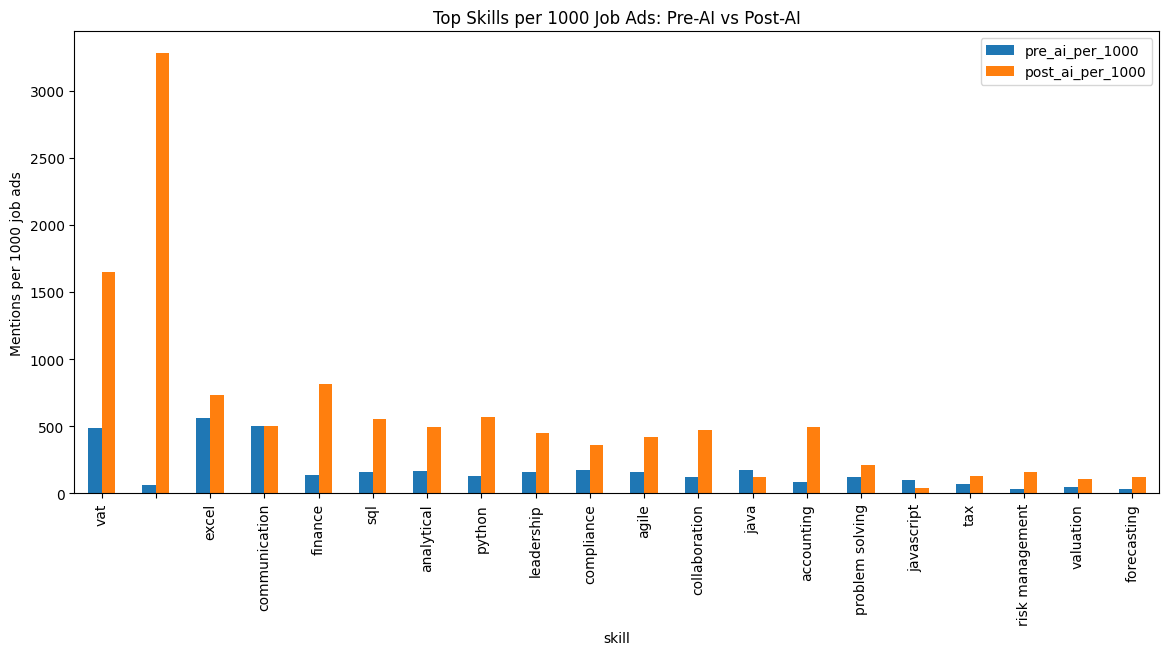

In [893]:
top_skills[["pre_ai_per_1000", "post_ai_per_1000"]].plot(
    kind="bar",
    figsize=(14,6),
    title="Top Skills per 1000 Job Ads: Pre-AI vs Post-AI",
    ylabel="Mentions per 1000 job ads"
)


# skills that increased after ai

In [895]:
skill_comparison["change"] = skill_comparison["post_ai_per_1000"] - skill_comparison["pre_ai_per_1000"]

skills_increased = skill_comparison.sort_values("change", ascending=False).head(50)
skills_increased


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total,change
skill,,,,,,
,817,9396,62.672599,3277.293338,10213,3214.620739
vat,6375,4723,489.030377,1647.366585,11098,1158.336208
finance,1755,2340,134.627186,816.184165,4095,681.556978
python,1708,1631,131.021786,568.887339,3339,437.865553
accounting,1121,1421,85.992636,495.640042,2542,409.647406
sql,2060,1591,158.023934,554.935473,3651,396.911539
collaboration,1603,1353,122.967168,471.921870,2956,348.954702
analytical,2213,1425,169.760663,497.035228,3638,327.274566
leadership,2038,1292,156.336299,450.645274,3330,294.308974


# skills that decreased the most

In [896]:
skills_decreased = skill_comparison.sort_values("change").head(20)
skills_decreased


,pre_ai,post_ai,pre_ai_per_1000,post_ai_per_1000,total,change
skill,,,,,,
javascript,1275,104,97.806075,36.274852,1379,-61.531224
java,2292,355,175.820804,123.822811,2647,-51.997993
gaap,206,17,15.802393,5.929543,223,-9.872850
communication,6577,1436,504.525928,500.871992,8013,-3.653937
accounts preparation,89,13,6.827248,4.534356,102,-2.292891
ifrs,184,36,14.114759,12.556679,220,-1.558080
auditing,181,36,13.884627,12.556679,217,-1.327948
cost accounting,43,7,3.298558,2.441577,50,-0.856981
corporate tax,18,4,1.380792,1.395187,22,0.014395
